## Bike details dataset analysis 

In [2]:
#importing liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection and cleaning

In [3]:
#loading dataset
df=pd.read_csv('Desktop/RHOMBIX PROJECT/BIKE DETAILS.csv')

In [4]:
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


## -- Data understanding

In [5]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [7]:
df.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [8]:
#checking the count of null values
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

### Observation
This dataset contains 1055 bike record with 7 features and 435 null values in 'ex_showroom_price' column.

## --Data cleaning
--missing values
--duplicates values
--outliers 

In [9]:
##missing values
#handling null values replacing with meadian
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df['ex_showroom_price'].median())

In [10]:
#checking after replacing null values with median
df.isnull().sum()

name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64

In [11]:
#Total duplicates
df.duplicated().sum()

np.int64(6)

In [12]:
#Duplicate rows
df[df.duplicated()]

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
231,TVS Apache RTR 200 4V,95000,2018,Individual,1st owner,9600,72752.5
508,Bajaj Pulsar 135 LS,20000,2010,Individual,1st owner,80000,64589.0
522,Bajaj Platina 100,20000,2012,Individual,1st owner,16295,72752.5
605,Hero Karizma [2003-2014],50000,2013,Individual,1st owner,38000,85766.0
607,Honda CB Hornet 160R,70000,2017,Individual,1st owner,35000,87719.0
773,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0


In [13]:
#removing  duplicates
df=df.drop_duplicates()


In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
#outliers
#counting the outliers
numeric_column = ['selling_price','year','km_driven','ex_showroom_price']
for col in numeric_column:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    print(f'{col}:{len(outliers)} outliers')

selling_price:87 outliers
year:18 outliers
km_driven:38 outliers
ex_showroom_price:120 outliers


### Observation
 Missing values were found 435 'ex_showroom_price' column and replace with median. Duplicates (6 rows) were removed. Outliers were identified selling_price:87  year:18  km_driven:38   ex_showroom_price:120 

### Performing EDA

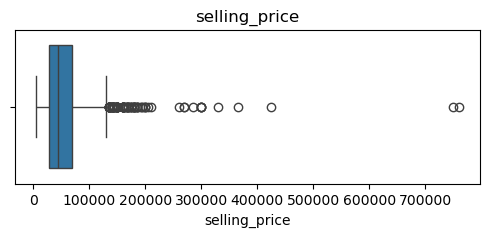

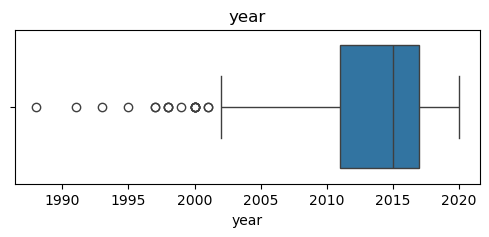

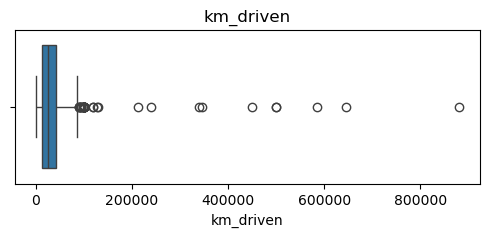

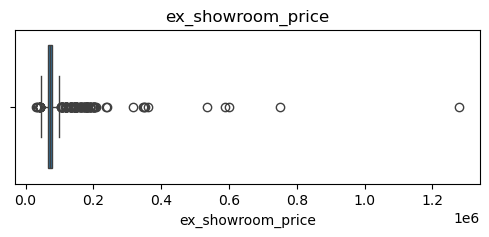

In [17]:
#checking for outliers through boxplot
numeric_column = ['selling_price','year','km_driven','ex_showroom_price']
for col in numeric_column:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show

## visualization
with

bar charts

histogram 

line graphs

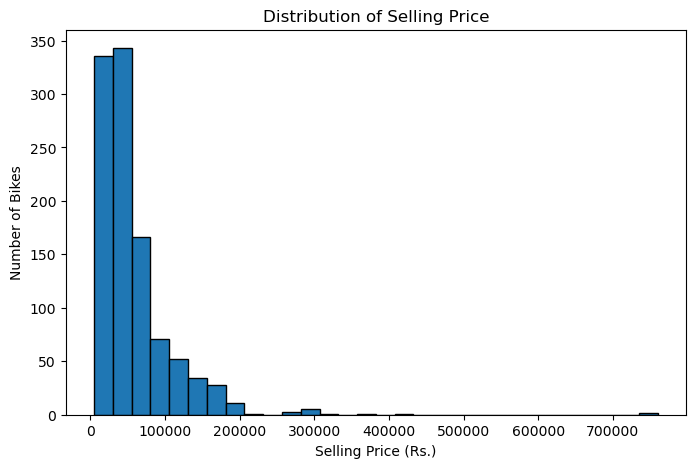

In [20]:
#histogram('selling price')
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30, edgecolor='black')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Rs.)')
plt.ylabel('Number of Bikes')
plt.show()

### Observation

- Most bikes have selling prices below Rs. 70,000.
- A few expensive bikes create a long right tail, indicating a positively skewed distribution.

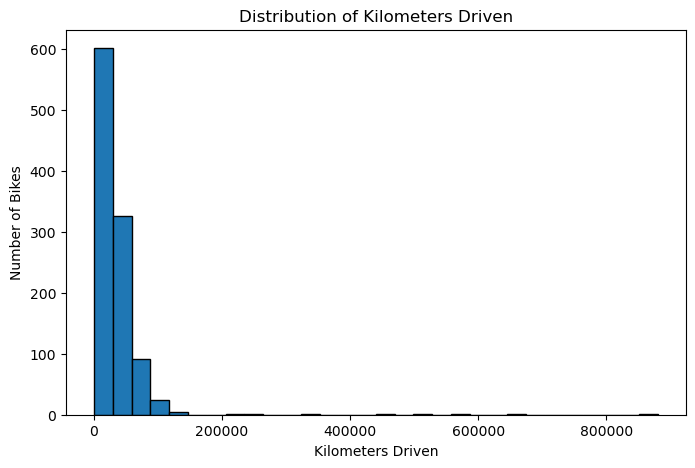

In [19]:
#histogram (KM driven)
plt.figure(figsize=(8,5))
plt.hist(df['km_driven'], bins=30, edgecolor='black')
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Number of Bikes')
plt.show()

### Observation

- Most bikes have been driven relatively fewer kilometers.
- A small number of bikes have very high mileage, resulting in a right-skewed distribution.

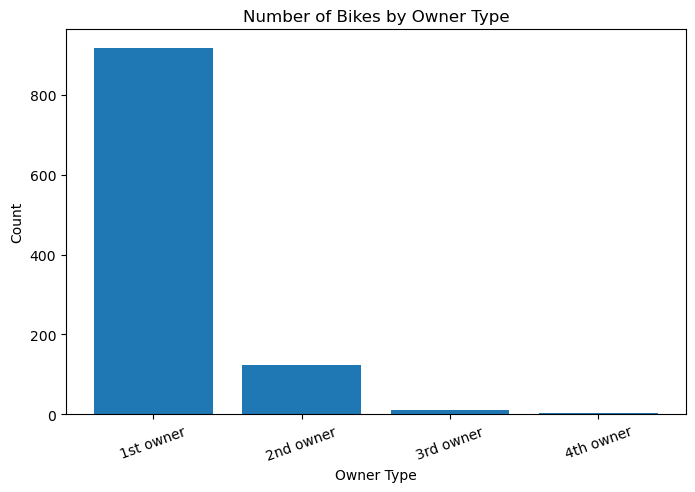

In [21]:
#bar chart (owner type)
owner_count = df['owner'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(owner_count.index, owner_count.values)
plt.title('Number of Bikes by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

### Observation

- First-owner bikes are the most common in the dataset.
- Bikes with three or more previous owners are much less frequent.

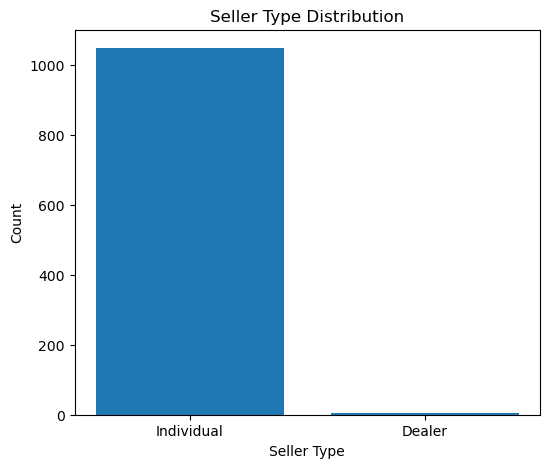

In [23]:
#Bar chart seller type
seller = df['seller_type'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(seller.index, seller.values)
plt.title('Seller Type Distribution')
plt.xlabel('Seller Type')
plt.ylabel('Count')
plt.show()

### Observation

- Most bikes are sold by individual sellers.
- Dealers contribute a smaller portion of the listings.

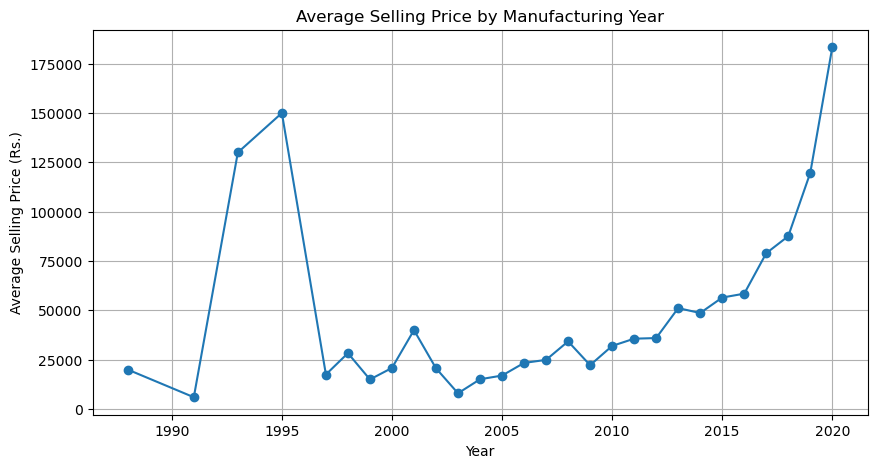

In [24]:
#LineGraph (average selling price by year)
year_price = df.groupby('year')['selling_price'].mean()

plt.figure(figsize=(10,5))
plt.plot(year_price.index, year_price.values, marker='o')
plt.title('Average Selling Price by Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price (Rs.)')
plt.grid(True)
plt.show()

### Observation

- Newer bike models generally have higher average selling prices.
- Older bikes tend to have lower resale values.

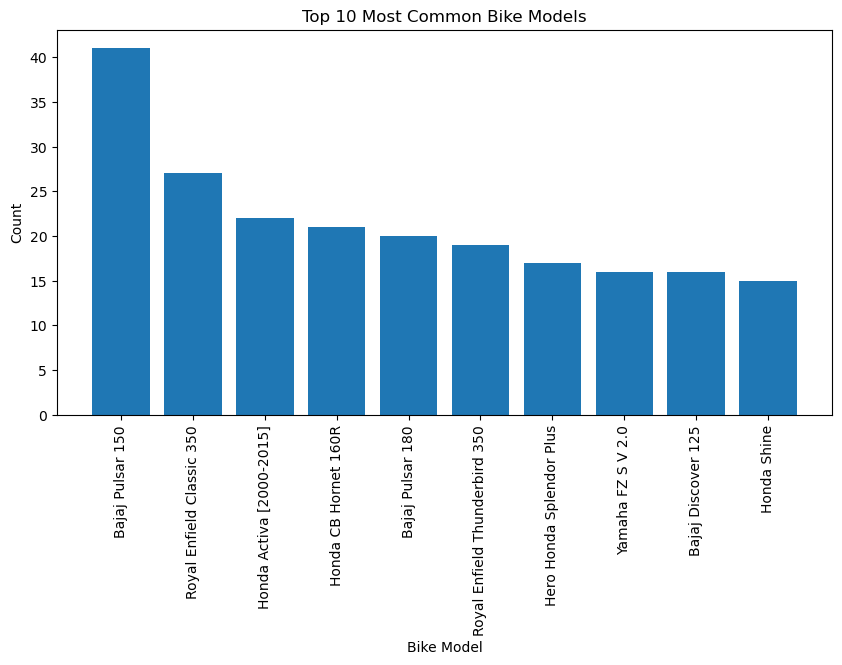

In [25]:
#bar chart(top10 most common bike models)
top_bikes = df['name'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_bikes.index, top_bikes.values)
plt.title('Top 10 Most Common Bike Models')
plt.xlabel('Bike Model')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

### Observation

- A few bike models appear much more frequently than others.
- The dataset includes a mix of popular and less common models.